an implementation of standard LR in jax

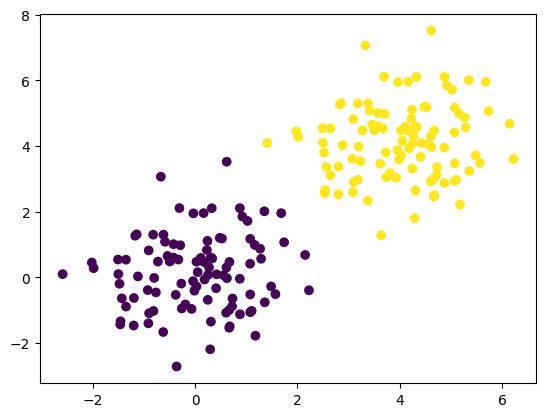

In [229]:
import jax
import jax.numpy as jnp
from jax import random
import matplotlib.pyplot as plt

key = random.key(20837143)
key2 = random.key(123)
key3 = random.key(4321)

X1 = random.normal(key, shape = (100, 2))
X2 = random.normal(key, shape = (100, 2)) + 4

X = jnp.concatenate([X1, X2], axis = 0)
Y = jnp.concatenate([jnp.zeros(100), jnp.ones(100)])

plt.scatter(X[:, 0], X[:, 1], c=Y)

In [233]:
@jax.jit
def forward(X, W, b):
    return 1 / (1 + jnp.exp(-(jnp.dot(X, W.T) + b)))

@jax.jit
def loss(params, X, y):
    eps = 1e-7
    y_pred = forward(X, params[0], params[1])
    y_pred = jnp.clip(y_pred, eps, 1 - eps)
    return -jnp.mean(y * jnp.log(y_pred) + (1 - y) * jnp.log(1 - y_pred))

@jax.jit
def step(X, Y, W, b, lr = 0.05):
    step_loss = loss((W, b), X, Y)
    loss_fn_grad = jax.grad(loss)((W, b), X, Y)
    W = W - (lr * loss_fn_grad[0])
    b = b - (lr * loss_fn_grad[1])
    return W, b, step_loss


0.058550682


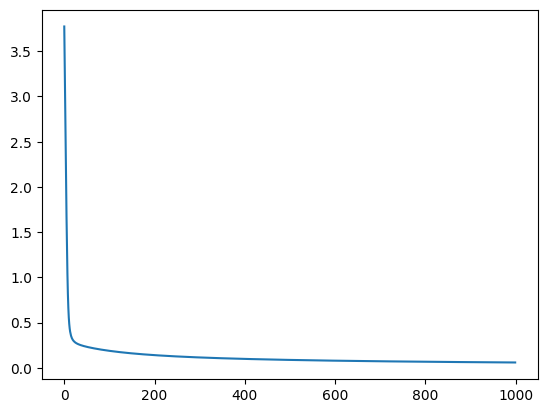

In [236]:
Wkey = random.key(191919)
W = random.normal(key = Wkey, shape = (2,))
b_key = random.key(13123)
b = random.normal(b_key)

loss_arr = []

for epoch in range(1000):
    W, b, step_loss = step(X, Y, W, b)
    loss_arr.append(step_loss)

plt.plot(jnp.arange(1000), loss_arr)
print(loss_arr[-1])

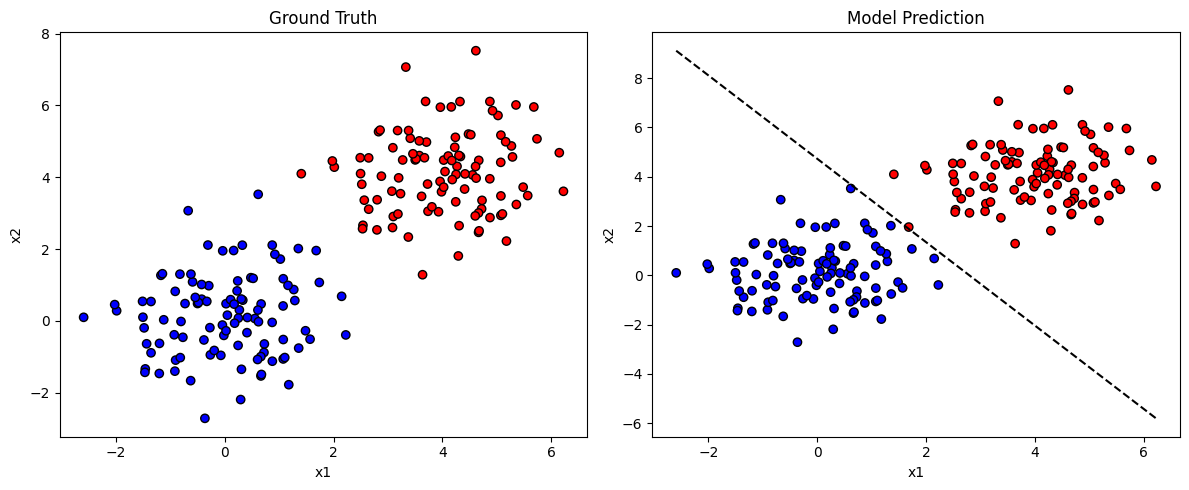

In [238]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

# Predicted probabilities
y_prob = forward(X, W, b)

# Convert to 0/1 predictions
y_pred = (y_prob >= 0.5).astype(int)

# Decision boundary
x_vals = jnp.linspace(X[:, 0].min(), X[:, 0].max(), 100)
y_vals = -(W[0] * x_vals + b) / W[1]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ----------------------
# Ground Truth
# ----------------------
ax[0].scatter(X[:, 0], X[:, 1], c=Y, cmap="bwr", edgecolors="k")
ax[0].set_title("Ground Truth")
ax[0].set_xlabel("x1")
ax[0].set_ylabel("x2")

# ----------------------
# Model Predictions
# ----------------------
ax[1].scatter(X[:, 0], X[:, 1], c=y_pred, cmap="bwr", edgecolors="k")
ax[1].plot(x_vals, y_vals, "k--")
ax[1].set_title("Model Prediction")
ax[1].set_xlabel("x1")
ax[1].set_ylabel("x2")

plt.tight_layout()
plt.show()